In [3]:
import numpy as np
import pandas as pd

In [5]:
from google.colab import files


uploaded = files.upload()

data = pd.read_csv("laptop_price.csv", encoding='ISO-8859-1')


data.head()

Saving laptop_price.csv to laptop_price.csv


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


#Filter Method

In [6]:
# Correlation with target (Price)
corr = data.corr(numeric_only=True)["Price_euros"].sort_values(ascending=False)
print(corr)

Price_euros    1.000000
Inches         0.068197
laptop_ID      0.067830
Name: Price_euros, dtype: float64


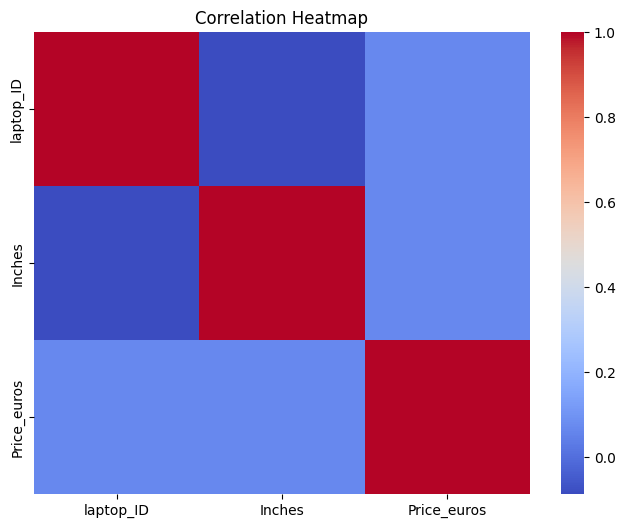

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#Embedded Method

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_encoded, y)

importances = pd.Series(rf.feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=False)

# Show top features
print(top_features.head(10))

TypeName_Notebook            0.295447
Ram_16GB                     0.091109
Inches                       0.080048
Ram_32GB                     0.077514
Ram_4GB                      0.050656
laptop_ID                    0.027950
Memory_1TB SSD               0.017748
TypeName_Workstation         0.016598
Memory_512GB SSD             0.016552
ScreenResolution_1366x768    0.015763
dtype: float64


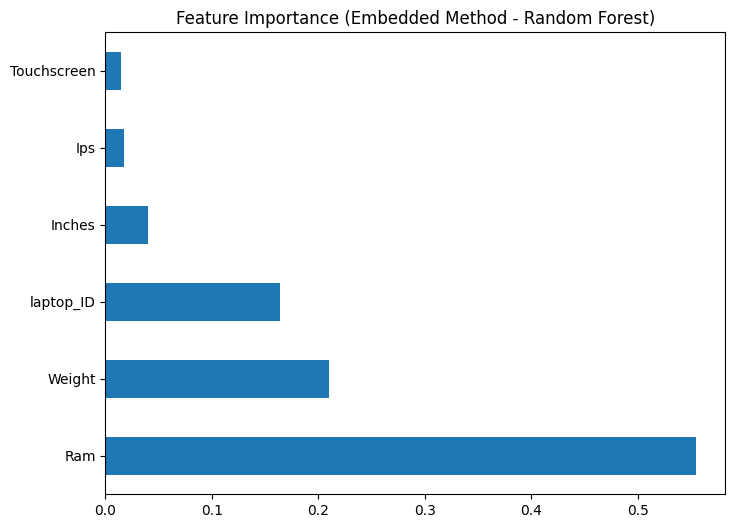

In [ ]:
# Plot
top_features.head(10).plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance (Embedded Method - Random Forest)")
plt.show()